In [28]:
# Notebook cell 1: imports
import h5py
import numpy as np
import pandas as pd

# If your UMAPTrainer is in a local module, import it like:
# from rail_umap.informer import UMAPTrainer
# For this notebook snippet, I'll assume UMAPTrainer is already importable:
from rail.estimation.algos.umap import UMAPTrainer  # <-- adjust to your actual path

from rail.core.stage import RailStage
from rail.core.data import TableHandle
DS = RailStage.data_store
DS.__class__.allow_overwrite = True

# Notebook cell 2: inspect the HDF5 file (see what groups/datasets exist)
trainingFile = "./data/roman_rubin_25.3.pq"
training_data = DS.read_file("training_data", TableHandle, trainingFile)


column_list None


In [29]:
bands = ['u', 'g', 'r', 'i', 'z', 'y', 'Y106', 'J129', 'H158', 'F184']
ref_band = "i"

In [30]:
# Notebook cell 4: define nondetect handling (UMAPTrainer expects mag_limits and nondetect_val)
# If your data uses a specific sentinel, set it here. Otherwise you can choose something safe.
nondetect_val = -99.0  # change if your file uses something else (e.g. 99, 30, NaN)

# Very simple fallback limits: replace nondetects with (max finite + 1) per band
mag_limits = {}
for b in bands:
    arr = np.asarray(training_data.data[b])
    finite = np.isfinite(arr)
    if finite.any():
        mag_limits[b] = float(np.nanmax(arr[finite]) + 1.0)
    else:
        mag_limits[b] = 30.0


In [31]:
nondetect_val

-99.0

In [36]:

umap_dict = dict(
    # I/O
    hdf5_groupname='',
    # feature construction (KNN-compatible)
    bands=bands,
    ref_band=ref_band,
    only_colors=True,
    nondetect_val=nondetect_val,
    mag_limits=mag_limits,
    # UMAP hyperparameters
    n_neighbors=80,
    min_dist=0.01,
    metric="manhattan",
    n_components=3,
    init="spectral",
    verbose=True,
    n_epochs=100,
)

trainer = UMAPTrainer.make_stage(
    name="umap_trainer_test",
    **umap_dict
)


model_handle = trainer.inform(training_data)
model = model_handle.data  # ModelHandle -> underlying object



/jet/home/ztq1996/.conda/envs/rail_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(metric='manhattan', min_dist=0.01, n_components=3, n_epochs=100, n_jobs=1, n_neighbors=80, random_state=0, verbose=True)
Wed Jan 21 20:00:01 2026 Construct fuzzy simplicial set
Wed Jan 21 20:00:01 2026 Finding Nearest Neighbors
Wed Jan 21 20:00:01 2026 Building RP forest with 13 trees
Wed Jan 21 20:00:01 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Wed Jan 21 20:00:10 2026 Finished Nearest Neighbor Search
Wed Jan 21 20:00:11 2026 Construct embedding


Epochs completed:   7%| ▋          7/100 [00:00]

	completed  0  /  100 epochs


Epochs completed:  13%| █▎         13/100 [00:01]

...

	completed  80  /  100 epochs


Epochs completed:  92%| █████████▏ 92/100 [00:11]

	completed  90  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:12]


Wed Jan 21 20:00:25 2026 Finished embedding
Inserting handle into data store.  model_umap_trainer_test: inprogress_model_umap_trainer_test.pkl, umap_trainer_test
Wed Jan 21 20:00:26 2026 Worst tree score: 0.99353733
Wed Jan 21 20:00:26 2026 Mean tree score: 0.99457555
Wed Jan 21 20:00:26 2026 Best tree score: 0.99582344
Wed Jan 21 20:00:27 2026 Forward diversification reduced edges from 1819680 to 185575
Wed Jan 21 20:00:27 2026 Reverse diversification reduced edges from 185575 to 185575
Wed Jan 21 20:00:27 2026 Degree pruning reduced edges from 219084 to 219084
Wed Jan 21 20:00:27 2026 Resorting data and graph based on tree order
Wed Jan 21 20:00:27 2026 Building and compiling search function


In [37]:
from rail.estimation.algos.umap import _computecolordata

umap_model = model["reducer"]
embedding = trainer.umap_transform(pd.DataFrame(training_data.data), umap_model)

print("Model keys:", model.keys())
print("UMAP model:", model["reducer"])
print("Embedding shape:", embedding.shape)

Model keys: dict_keys(['reducer', 'bands', 'ref_band', 'only_colors'])
UMAP model: UMAP(metric='manhattan', min_dist=0.01, n_components=3, n_epochs=100, n_jobs=1, n_neighbors=80, random_state=0, verbose=True)
Embedding shape: (22746, 3)


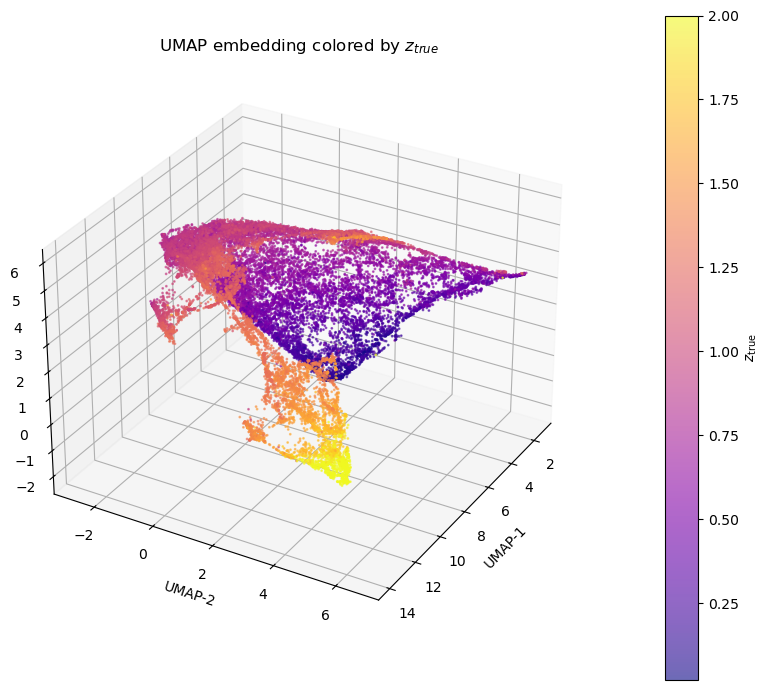

In [39]:


# Notebook cell 6: quick visualization of the embedding (3D scatter)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

z_true = np.asarray(training_data.data["z_true"])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=z_true,
    cmap="plasma",
    s=1,
    alpha=0.6,
    vmax=2.0
)
ax.view_init(elev=30, azim=30)

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")
ax.set_title("UMAP embedding colored by $z_{true}$")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label(r"$z_{\rm true}$")

plt.tight_layout()
plt.show()